# Sales Performance & Profitability Analysis

## Project Structure

This notebook follows a structured analytics workflow:

1. Business objective definition  
2. Environment setup and library imports  
3. Data loading and validation  
4. Data cleaning and wrangling  
5. Feature engineering  
6. Exploratory data analysis (EDA)  
7. Business insights and strategic recommendations  


## Business Objective 

- The goal of this analysis is to evaluate sales performance, profitability, and regional efficiency using KPIs such as revenue, margin, and order volume to identify growth opportunities.

### Key KPIs
- Total Revenue
- Total Profit
- Profit Margin
- Order Volume
- Regional Performance
- Product Category Performance

***Problem Statement***

- XYZ Corporation aims to analyze its sales data from 2014 to 2018 to uncover actionable insights that drive revenue growth and profitability.

In [1]:
# Important Library and environment setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import warnings

# Ignoring unnecessary warnings for cleaner output
warnings.filterwarnings("ignore")

# Configuring logging for execution tracking
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# Setting visualization style for clear, business-friendly charts
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

logging.info("Libraries imported successfully")
logging.info("Visualization environment configured")

2026-02-20 17:48:53,950 - INFO - Libraries imported successfully
2026-02-20 17:48:53,952 - INFO - Visualization environment configured


In [2]:
# Loading Dataset

file_path = "Regional Sales Dataset.xlsx"

try:
    sheets = pd.read_excel(file_path, sheet_name=None)
    logging.info(f"Dataset loaded successfully. Sheets found: {list(sheets.keys())}")
except FileNotFoundError:
    logging.error("Dataset file not found. Please check the path.")
except Exception as e:
    logging.error(f"Error loading file: {e}")

2026-02-20 17:49:06,051 - INFO - Dataset loaded successfully. Sheets found: ['Sales Orders', 'Customers', 'Regions', 'State Regions', 'Products', '2017 Budgets']


In [3]:
# Assigning dataframes to each sheet

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budgets = sheets['2017 Budgets']

logging.info("DataFrames assigned successfully.")

2026-02-20 17:49:06,062 - INFO - DataFrames assigned successfully.


In [4]:
datasets = {
    "Sales": df_sales,
    "Customers": df_customers,
    "Products": df_products,
    "Regions": df_regions,
    "State Regions": df_state_reg,
    "Budgets": df_budgets
}

for name, df in datasets.items():
    logging.info(f"{name} shape: {df.shape}")

2026-02-20 17:49:06,073 - INFO - Sales shape: (64104, 12)
2026-02-20 17:49:06,076 - INFO - Customers shape: (175, 2)
2026-02-20 17:49:06,077 - INFO - Products shape: (30, 2)
2026-02-20 17:49:06,077 - INFO - Regions shape: (994, 15)
2026-02-20 17:49:06,078 - INFO - State Regions shape: (49, 3)
2026-02-20 17:49:06,079 - INFO - Budgets shape: (30, 2)


In [5]:
#Shapes of each Dataframes

for name, df in datasets.items():
    logging.info(f"{name} shape: {df.shape}")

2026-02-20 17:49:06,089 - INFO - Sales shape: (64104, 12)
2026-02-20 17:49:06,090 - INFO - Customers shape: (175, 2)
2026-02-20 17:49:06,092 - INFO - Products shape: (30, 2)
2026-02-20 17:49:06,092 - INFO - Regions shape: (994, 15)
2026-02-20 17:49:06,092 - INFO - State Regions shape: (49, 3)
2026-02-20 17:49:06,094 - INFO - Budgets shape: (30, 2)


# Checking & Dealing with the Dataframes

In [6]:
# Previewing sales order data
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


### Initial Data Observations
- Dataset contains transactional sales records
- Includes customer, product, and regional attributes

In [7]:
# Previewing customer master data
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


### Data Quality Check
This step checks missing values that could affect analysis results.

In [8]:
# Previewing product catalog data
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [9]:
# Previewing Regions data
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [10]:
# Previewing Budget data
df_budgets.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [11]:
# Previewing State reg data
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [12]:
# Correcting Row Headers
if df_state_reg.columns[0].lower() != "state code":
    df_state_reg.columns = df_state_reg.iloc[0]
    df_state_reg = df_state_reg[1:].reset_index(drop=True)
    logging.warning("Header row corrected for df_state_reg.")
else:
    logging.info("df_state_reg header is already correct.")

2026-02-20 17:49:06,208 - WARNING - Header row corrected for df_state_reg.


In [13]:
df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [14]:
# Auditing a DataFrame for missing values, data types, and uniqueness
def audit_dataframe(df, name):
    logging.info(f"Auditing {name}")

    audit = pd.DataFrame({
        "Null_Count": df.isnull().sum(),
        "Null_Percentage": (df.isnull().mean() * 100).round(2),
        "Unique_Values": df.nunique(),
        "Data_Type": df.dtypes.astype(str)
    })

    if audit["Null_Count"].sum() == 0:
        logging.info(f"{name}: No missing values found")
        display(audit)
    else:
        logging.warning(f"{name}: Missing values detected")
        display(audit[audit["Null_Count"] > 0])

    return audit

In [15]:
audit_sales = audit_dataframe(df_sales, "Sales")
audit_customers = audit_dataframe(df_customers, "Customers")
audit_products = audit_dataframe(df_products, "Products")
audit_regions = audit_dataframe(df_regions, "Regions")
audit_state_reg = audit_dataframe(df_state_reg,"State_reg")
audit_budgets = audit_dataframe(df_budgets,"Budgets")

2026-02-20 17:49:06,242 - INFO - Auditing Sales
2026-02-20 17:49:06,297 - INFO - Sales: No missing values found


,Null_Count,Null_Percentage,Unique_Values,Data_Type
OrderNumber,0,0.0,10684,object
OrderDate,0,0.0,1520,datetime64[ns]
Customer Name Index,0,0.0,175,int64
Channel,0,0.0,3,object
Currency Code,0,0.0,1,object
Warehouse Code,0,0.0,4,object
Delivery Region Index,0,0.0,993,int64
Product Description Index,0,0.0,30,int64
Order Quantity,0,0.0,8,int64
Unit Price,0,0.0,664,float64


2026-02-20 17:49:06,306 - INFO - Auditing Customers
2026-02-20 17:49:06,310 - INFO - Customers: No missing values found


,Null_Count,Null_Percentage,Unique_Values,Data_Type
Customer Index,0,0.0,175,int64
Customer Names,0,0.0,175,object


2026-02-20 17:49:06,314 - INFO - Auditing Products
2026-02-20 17:49:06,318 - INFO - Products: No missing values found


...

,Null_Count,Null_Percentage,Unique_Values,Data_Type
id,0,0.0,994,int64
name,0,0.0,923,object
county,0,0.0,412,object
state_code,0,0.0,48,object
state,0,0.0,48,object
type,0,0.0,12,object
latitude,0,0.0,990,float64
longitude,0,0.0,990,float64
area_code,0,0.0,220,int64
population,0,0.0,972,int64


2026-02-20 17:49:06,337 - INFO - Auditing State_reg
2026-02-20 17:49:06,342 - INFO - State_reg: No missing values found


,Null_Count,Null_Percentage,Unique_Values,Data_Type
0,,,,
State Code,0,0.0,48,object
State,0,0.0,48,object
Region,0,0.0,4,object


2026-02-20 17:49:06,351 - INFO - Auditing Budgets
2026-02-20 17:49:06,355 - INFO - Budgets: No missing values found


,Null_Count,Null_Percentage,Unique_Values,Data_Type
Product Name,0,0.0,30,object
2017 Budgets,0,0.0,30,float64


## Handling Missing Values

Missing values can negatively impact analysis accuracy.  
In this project:
- Numerical columns are filled using median values to avoid distortion caused by outliers.
- Categorical columns are filled using the mode (most frequent value).
- Rows with critical missing fields are removed where necessary.

This approach ensures data integrity while retaining maximum usable records.

In [16]:
# Checking missing values across all datasets
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]

    if not nulls.empty:
        logging.warning(f"Missing values found in {name}:\n{nulls}")
    else:
        logging.info(f"No missing values in {name}")

2026-02-20 17:49:06,377 - INFO - No missing values in Sales
2026-02-20 17:49:06,379 - INFO - No missing values in Customers
2026-02-20 17:49:06,380 - INFO - No missing values in Products
2026-02-20 17:49:06,382 - INFO - No missing values in Regions
2026-02-20 17:49:06,385 - INFO - No missing values in State Regions
2026-02-20 17:49:06,387 - INFO - No missing values in Budgets


In [17]:
# Checking data types for consistency
for name, df in datasets.items():
    logging.info(f"{name} data types:\n{df.dtypes}")

2026-02-20 17:49:06,395 - INFO - Sales data types:
OrderNumber                          object
OrderDate                    datetime64[ns]
Customer Name Index                   int64
Channel                              object
Currency Code                        object
Warehouse Code                       object
Delivery Region Index                 int64
Product Description Index             int64
Order Quantity                        int64
Unit Price                          float64
Line Total                          float64
Total Unit Cost                     float64
dtype: object
2026-02-20 17:49:06,396 - INFO - Customers data types:
Customer Index     int64
Customer Names    object
dtype: object
2026-02-20 17:49:06,400 - INFO - Products data types:
Index            int64
Product Name    object
dtype: object
2026-02-20 17:49:06,402 - INFO - Regions data types:
id                 int64
name              object
county            object
state_code        object
state             obj

In [18]:
# Checking duplicate rows in each dataset
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    logging.info(f"{name} duplicate rows: {dup_count}")

2026-02-20 17:49:06,459 - INFO - Sales duplicate rows: 0
2026-02-20 17:49:06,461 - INFO - Customers duplicate rows: 0
2026-02-20 17:49:06,462 - INFO - Products duplicate rows: 0
2026-02-20 17:49:06,466 - INFO - Regions duplicate rows: 0
2026-02-20 17:49:06,467 - INFO - State Regions duplicate rows: 0
2026-02-20 17:49:06,468 - INFO - Budgets duplicate rows: 0


In [19]:
# Standardizing column names (strip spaces, lowercase, replace spaces with underscores) across all datasets

def standardize_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

for name, df in datasets.items():
    datasets[name] = standardize_columns(df)

logging.info("Column names standardized across all datasets.")

2026-02-20 17:49:06,483 - INFO - Column names standardized across all datasets.


### **Data Cleaning & Wrangling**

- This section focuses on preparing data for accurate analysis.

In [20]:
# Merging All DataFrames

df = df_sales.copy()

# Merging Customers
df = df.merge(
    df_customers,
    left_on="customer_name_index",
    right_on="customer_index",
    how="left",
    validate="m:1"
)

# Merging Regions

df = df.merge(
    df_regions,
    left_on="delivery_region_index",
    right_on="id",
    how="left",
    validate="m:1"
)

# Merging Products

df = df.merge(
    df_products,
    left_on="product_description_index",
    right_on="index",
    how="left",
    validate="m:1"
)

# Converting Date

df["orderdate"] = pd.to_datetime(df["orderdate"], errors="coerce")
df["year"] = df["orderdate"].dt.year

# Merging Budget (Product-Level Budget)

df = df.merge(
    df_budgets,
    on="product_name",
    how="left",
    validate="m:1"
)

# Dropping Technical Key Columns

df.drop(columns=[
    "customer_index",
    "id",
    "index"
], inplace=True, errors="ignore")

logging.info(f"Final merged dataframe shape: {df.shape}")
print("Final shape:", df.shape)

2026-02-20 17:49:06,677 - INFO - Final merged dataframe shape: (64104, 30)


Final shape: (64104, 30)


In [21]:
# Post-Merge Row Validation
logging.info("Validating merged dataset...")

if df.shape[0] != df_sales.shape[0]:
    logging.warning("Row count mismatch after merge!")
else:
    logging.info("Merge validation successful. No row loss detected.")

2026-02-20 17:49:06,690 - INFO - Validating merged dataset...
2026-02-20 17:49:06,692 - INFO - Merge validation successful. No row loss detected.


In [22]:
# Exporting merged dataset for validation 
df.to_csv("merged_sales_data.csv", index=False)

In [23]:
# Renaming columns 

df = df.rename(columns = {'ordernumber':'order_number','orderdate':'order_date','customer_names':'customer_name',
               'line_total':'revenue','total_unit_cost':'cost','state':'state_name','2017_budgets':'budget'
               })
df.head(1)

,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,order_quantity,unit_price,...,area_code,population,households,median_income,land_area,water_area,time_zone,product_name,year,budget
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,Product 27,2014,964940.231


In [24]:
# Blanking out budgets for non-2017 orders
df.loc[df['order_date'].dt.year !=2017,'budget'] = pd.NA

df[['order_date','product_name','revenue','budget']].head()

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [25]:
# Inspecting final dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   order_number               64104 non-null  object        
 1   order_date                 64104 non-null  datetime64[ns]
 2   customer_name_index        64104 non-null  int64         
 3   channel                    64104 non-null  object        
 4   currency_code              64104 non-null  object        
 5   warehouse_code             64104 non-null  object        
 6   delivery_region_index      64104 non-null  int64         
 7   product_description_index  64104 non-null  int64         
 8   order_quantity             64104 non-null  int64         
 9   unit_price                 64104 non-null  float64       
 10  revenue                    64104 non-null  float64       
 11  cost                       64104 non-null  float64       
 12  cust

In [26]:
# Filtering 2017 dataset
df_2017 = df[df['order_date'].dt.year == 2017]

In [27]:
df_2017.head()

,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,order_quantity,unit_price,...,area_code,population,households,median_income,land_area,water_area,time_zone,product_name,year,budget
46363,SO - 0002544,2017-01-01,107,Wholesale,USD,NXH382,711,30,6,1239.5,...,551,69156,23029,41107,3333346,0,America/New York,Product 30,2017,1011609.684
46364,SO - 0006431,2017-01-01,116,Wholesale,USD,NXH382,234,13,5,1829.1,...,970,60358,24290,45358,101735554,921925,America/Denver,Product 13,2017,3720639.645
46365,SO - 0007491,2017-01-01,45,Wholesale,USD,NXH382,108,15,9,2412.0,...,424,111666,36667,42044,23485845,63502,America/Los Angeles,Product 15,2017,3299478.315
46366,SO - 0008741,2017-01-01,169,Wholesale,USD,GUT930,375,8,8,904.5,...,563,58799,23901,47450,78952077,2802123,America/Chicago,Product 8,2017,1085037.329
46367,SO - 0009295,2017-01-01,20,Wholesale,USD,NXH382,339,2,12,1112.2,...,352,100270,39038,41308,154983928,6194314,America/New York,Product 2,2017,3050087.565


### Feature Engineering

In [28]:
# Calculating total cost, profit, and profit margin percentage

df['total_cost'] = df['order_quantity'] * df['cost']

df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin_pct'] = np.where(
    df['revenue'] != 0,
    (df['profit'] / df['revenue']) * 100,0).round(2)

In [29]:
# Calculating overall business performance metrics

total_profit = df['profit'].sum()

overall_profit_margin = (df['profit'].sum() / df['revenue'].sum()) * 100

total_revenue = df['revenue'].sum()

aov = total_revenue / max(df['order_number'].nunique(), 1)

In [30]:
print("Total Revenue: ${:,.2f}".format(total_revenue))
print("Total Profit: ${:,.2f}".format(total_profit))
print("Overall Profit Margin: {:.2f}%".format(overall_profit_margin))
print("Average Order Value: ${:,.2f}".format(aov))

Total Revenue: $1,235,968,899.00
Total Profit: $461,772,559.92
Overall Profit Margin: 37.36%
Average Order Value: $115,684.10


In [31]:
df.head()

,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,order_quantity,unit_price,...,median_income,land_area,water_area,time_zone,product_name,year,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,36466,268318796,13908113,America/New York,Product 27,2014,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,54176,72276415,1883,America/Indiana/Indianapolis,Product 20,2014,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,124759,62489257,386195,America/Los Angeles,Product 26,2014,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,30019,60221613,475857,America/Indiana/Indianapolis,Product 7,2014,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,63158,70972793,720300,America/New York,Product 8,2014,NaN,10082.160,8249.040,45.0


In [32]:
# Executive KPI Snapshot

kpis = {
    "Total Revenue": df["revenue"].sum(),
    "Total Profit": df["profit"].sum(),
    "Overall Profit Margin (%)": df["profit"].sum() / df["revenue"].sum() * 100,
    "Total Orders": df["order_number"].nunique(),
    "Active Regions": df["name"].nunique(),
    "Active Products": df["product_name"].nunique()
}

pd.DataFrame.from_dict(kpis, orient="index", columns=["Value"])

,Value
Total Revenue,1.235969e+09
Total Profit,4.617726e+08
Overall Profit Margin (%),3.736118e+01
Total Orders,1.068400e+04
Active Regions,9.220000e+02
Active Products,3.000000e+01


### EDA

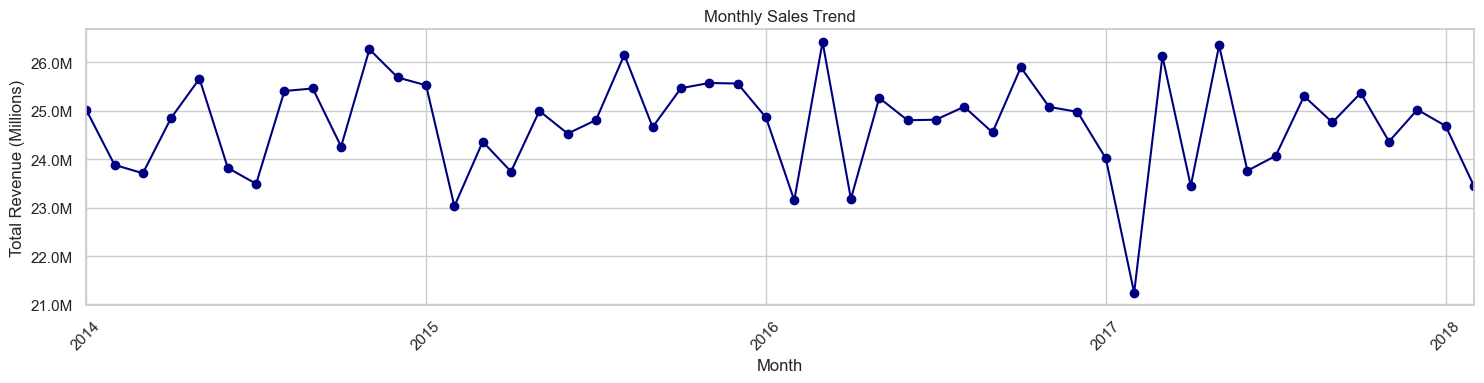

In [33]:
# Monthly Sales Trend Over Time

df['order_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize = (15,4))

monthly_sales.plot(marker = 'o',color = 'navy')

from matplotlib.ticker import FuncFormatter

# Formatting Y-axis values into Millions (M)

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Titles and labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

# Rotating x-axis labels for readability
plt.xticks(rotation=45)

# Adjust layout so labels don’t overlap
plt.tight_layout()

# Display the plot
plt.show()

In [34]:
# Removing partial 2018 data to avoid incomplete period bias

df['order_date'] = pd.to_datetime(df['order_date'])

df_new = df[
    ~((df['order_date'].dt.year == 2018) &
      (df['order_date'].dt.month.isin([1, 2])))
]

In [35]:
# If df_new is filtered from another DF
df_new = df_new.copy()

df_new['month'] = df_new['order_date'].dt.month_name()

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df_new['month'] = pd.Categorical(
    df_new['month'],
    categories=month_order,
    ordered=True
)

monthly_revenue = (
    df_new
    .groupby('month', observed=True)['revenue']
    .sum()
    .reset_index()
)

2026-02-20 17:49:08,392 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-20 17:49:08,395 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


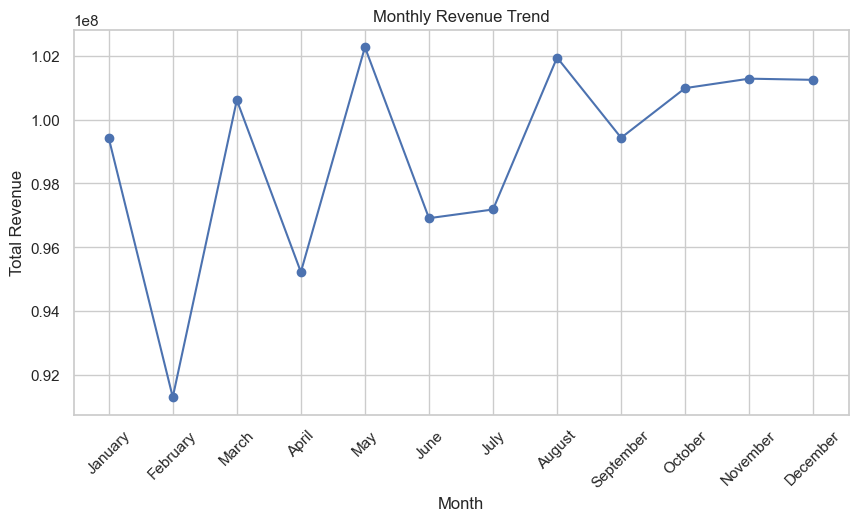

In [36]:
# Monthly Revenue Trend

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'], marker='o')

plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Monthly Revenue Trend')

plt.xticks(rotation=45)
plt.grid(True) 

plt.show()

In [37]:
top_10_products = (
    df_new
    .groupby('product_name', as_index=False)['revenue']
    .sum()
    .sort_values(by='revenue', ascending=False)
    .head(10)
)

top_10_products

,product_name,revenue
18,Product 26,112454990.9
17,Product 25,105715762.4
4,Product 13,75190019.7
5,Product 14,72516666.1
25,Product 5,68032711.2
6,Product 15,64933726.7
11,Product 2,54976803.1
24,Product 4,54558669.5
0,Product 1,53678832.2
22,Product 3,49935227.3


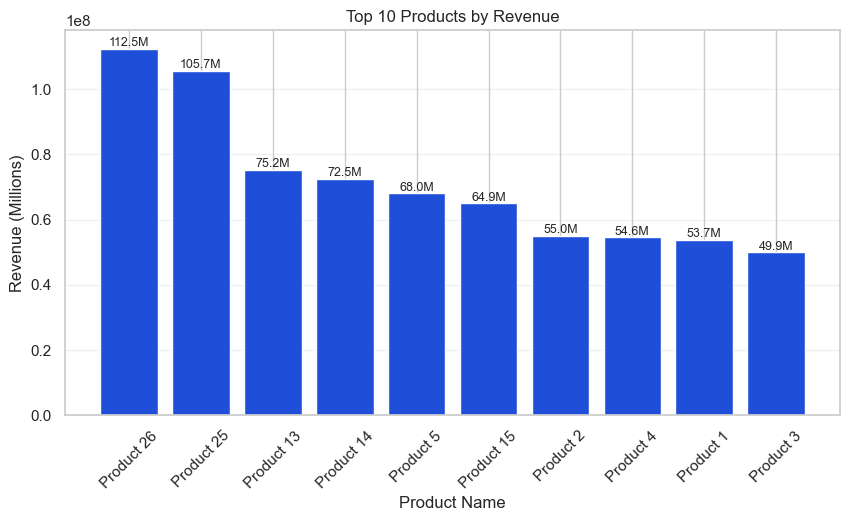

In [38]:
# Top 10 Products By Revenue

plt.figure(figsize=(10, 5))

bars = plt.bar(
    top_10_products['product_name'],
    top_10_products['revenue'],
    color='#1f4fd8'
)

plt.xlabel('Product Name')
plt.ylabel('Revenue (Millions)')
plt.title('Top 10 Products by Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adding Values on Bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height/1_000_000:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()

## Revenue Trends Analysis

This section analyzes how sales revenue changes over time to identify growth patterns,
seasonality, and overall business performance.


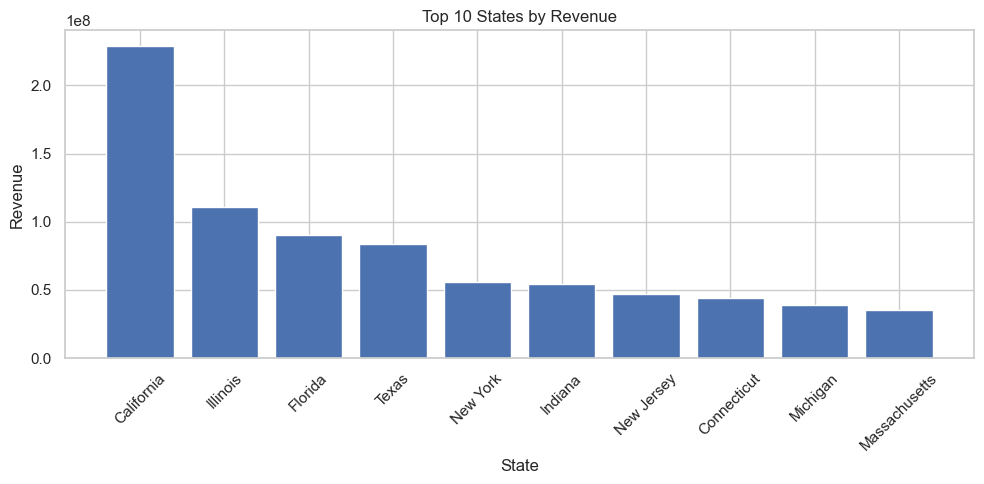

In [39]:
# Top 10 States Contributing to Total Revenue

top_regions = (
    df.groupby("state_name", as_index=False)["revenue"]
    .sum()
    .sort_values(by="revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(top_regions["state_name"], top_regions["revenue"])
plt.xticks(rotation=45)
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

 Insight:
Revenue is highly concentrated in the top-performing regions, with the top 10 regions contributing a majority share of total sales. This indicates an opportunity to prioritize these regions for retention and upselling, while underperforming regions may require targeted marketing or operational optimization.

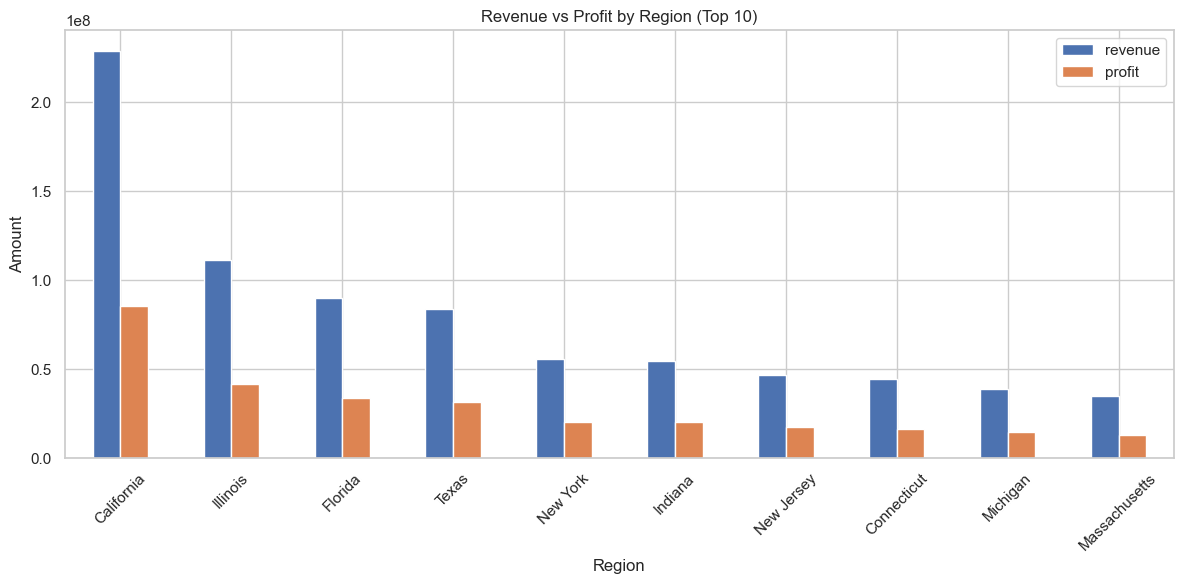

In [40]:
# Revenue vs Profit by Region (Top 10)
region_perf = (
    df.groupby("state_name")[["revenue", "profit"]]
      .sum()
      .sort_values("revenue", ascending=False)
      .head(10)
)

region_perf.plot(kind="bar", figsize=(12, 6))
plt.title("Revenue vs Profit by Region (Top 10)")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight:
While some regions generate high revenue, their profit contribution is comparatively lower, indicating higher operational or logistics costs. This suggests that revenue alone is not a sufficient performance metric and regional cost efficiency should be reviewed.

##  Product Performance Analysis

This section evaluates product-level sales performance to identify top-performing
and underperforming products contributing to overall revenue.


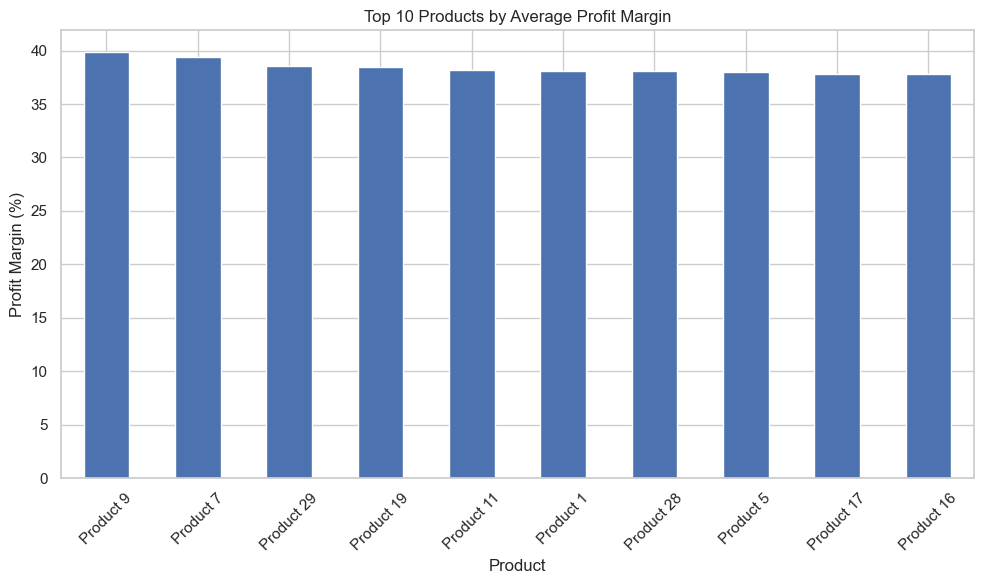

In [41]:
# Top 10 Products by Profit Margin

product_margin = (
    df.groupby("product_name")["profit_margin_pct"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
product_margin.plot(kind="bar")
plt.title("Top 10 Products by Average Profit Margin")
plt.xlabel("Product")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight:
Several products exhibit high profit margins despite not necessarily being the highest in sales volume. This highlights opportunities to increase focus on high-margin products through targeted promotions and pricing strategies.

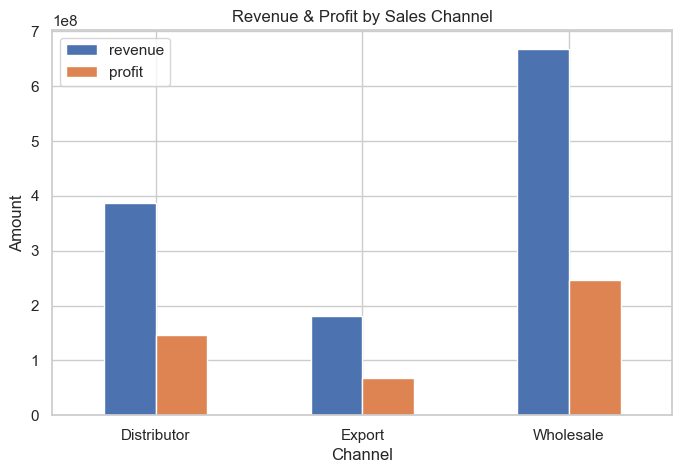

In [42]:
# Revenue and Profit by Channel

channel_perf = (
    df.groupby("channel")[["revenue", "profit"]].sum())

channel_perf.plot(kind="bar", figsize=(8,5))
plt.title("Revenue & Profit by Sales Channel")
plt.xlabel("Channel")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

 Insight:
Sales channels differ significantly in profitability. Some channels generate strong revenue but relatively lower profit, suggesting higher customer acquisition or fulfillment costs. Optimizing channel strategy could improve overall margins.

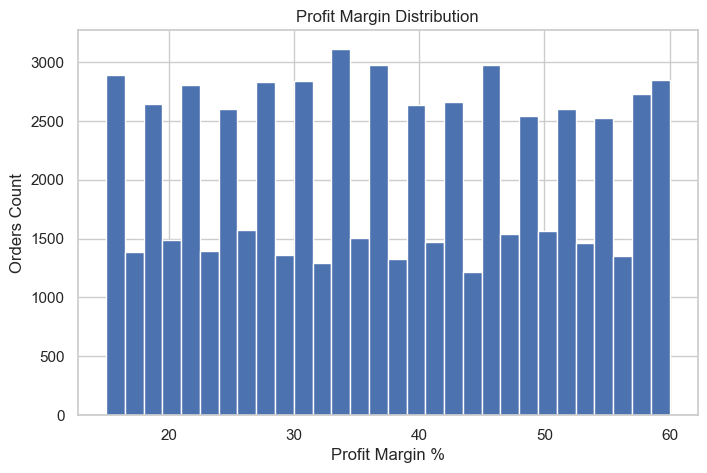

In [43]:
plt.figure(figsize=(8,5))
plt.hist(df["profit_margin_pct"], bins=30)
plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin %")
plt.ylabel("Orders Count")
plt.show()

Insights : Majority of orders operate within a narrow margin band, indicating pricing sensitivity.

## Regional Sales Performance

This section analyzes sales distribution across different regions to understand
regional demand patterns and identify high and low-performing markets.

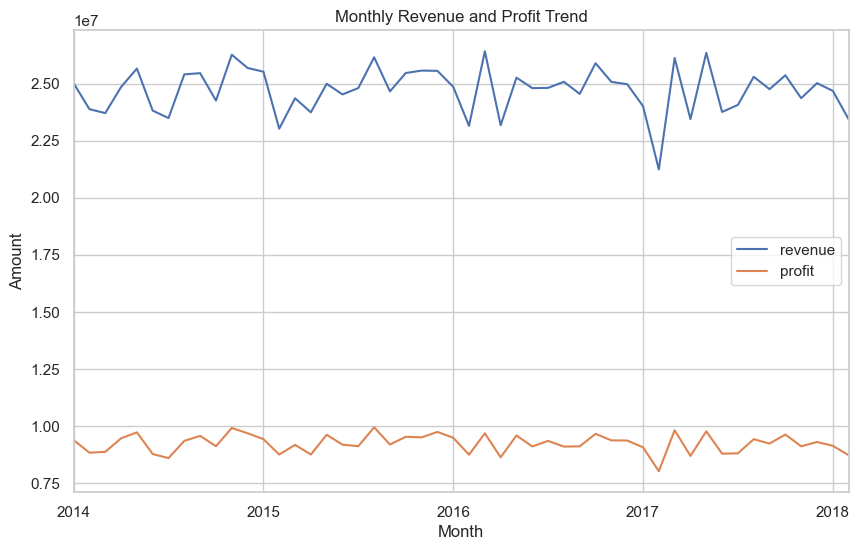

In [44]:
# Monthly Revenue and Profit Trend

monthly_perf = (
    df.groupby("order_month")[["revenue", "profit"]]
      .sum()
)

monthly_perf.plot(figsize=(10, 6))
plt.title("Monthly Revenue and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

 Insight:
Revenue and profit demonstrate clear seasonal patterns, with certain months consistently outperforming others. This suggests seasonality in demand and highlights opportunities for inventory planning, workforce optimization, and time-bound marketing campaigns.

## Key Insights & Business Recommendations

- The highest revenue is generated by a small set of categories, indicating opportunities for targeted promotions.
- Certain regions show strong sales volume but lower profit margins, suggesting pricing or cost inefficiencies.
- Monthly sales trends reveal seasonality, which can be leveraged for inventory planning and marketing campaigns.
- A small percentage of customers contribute to a large portion of total revenue, supporting a focused customer retention strategy.

### Business Recommendations
- Increase marketing spend in high-margin but low-volume regions.
- Optimize pricing strategies in regions with low profitability.
- Introduce loyalty programs for top-performing customers.
- Use seasonal trends to improve demand forecasting and inventory control.

## Tools & Technologies Used

- Python (Pandas, NumPy, Matplotlib, Seaborn)
- Exploratory Data Analysis (EDA)
- Data Cleaning & Feature Engineering
- KPI Calculation (Revenue, Profit, Margin)
- Data Visualization

Next Phase:
- SQL for querying cleaned datasets
- Power BI for interactive dashboards

## Conclusion

This analysis demonstrates an end-to-end sales performance evaluation using Python,
covering data cleaning, transformation, exploratory data analysis, and business insights.
The findings can support data-driven decision-making and future performance optimization.

In [45]:
# High Revenue but Low Margin Products

product_perf = (
    df.groupby("product_name")
      .agg(
          total_revenue=("revenue", "sum"),
          avg_profit_margin_pct=("profit_margin_pct", "mean")
      )
      .sort_values(by="total_revenue", ascending=False)
      .head(10)
)

product_perf

,total_revenue,avg_profit_margin_pct
product_name,,
Product 26,117291821.4,37.606275
Product 25,109473966.6,37.416416
Product 13,78281379.6,37.194529
Product 14,75390396.6,36.237947
Product 5,70804380.6,38.008961
Product 15,67331623.2,36.602273
Product 2,57401097.6,35.878558
Product 4,56701537.2,37.020790
Product 1,55952289.6,38.134298


Insights : Some top-selling products generate volume but erode margins, signaling pricing or cost issues.

In [46]:
# State-level summary of top 10 regions by revenue

summary= (
    df.groupby("state_name")
      .agg(
          orders=("order_number", "count"),
          revenue=("revenue", "sum"),
          profit=("profit", "sum"),
          avg_margin=("profit_margin_pct", "mean")
      )
      .sort_values("revenue", ascending=False)
      .head(10)
)

summary

,orders,revenue,profit,avg_margin
state_name,,,,
California,12000,228785436.0,8.550839e+07,37.232917
Illinois,5682,111050965.7,4.151722e+07,37.491904
Florida,4601,90204679.5,3.361911e+07,37.184742
Texas,4289,84011903.0,3.144253e+07,37.297272
New York,2829,55534960.0,2.055558e+07,37.461647
Indiana,2830,54601690.2,2.044501e+07,37.450883
New Jersey,2378,46830956.5,1.725970e+07,36.932296
Connecticut,2264,44251228.7,1.649437e+07,37.268110
Michigan,2039,39025315.8,1.478674e+07,37.662580


## Overall Business Insights

- Revenue is concentrated in a limited number of regions and products, indicating a strong Pareto effect.
- Profitability varies significantly across regions, products, and channels, highlighting cost structure differences.
- High-margin products represent an opportunity for strategic growth beyond volume-driven sales.
- Seasonal trends suggest predictable demand cycles that can be leveraged for better planning and profitability.

## Strategic Recommendations

- Focus customer retention and cross-selling efforts on high-revenue, high-profit regions.
- Review cost structures in high-revenue but low-margin regions to improve profitability.
- Expand promotion of high-margin products to accelerate sustainable growth.
- Reallocate sales efforts toward channels with stronger profit performance.
- Plan inventory and workforce capacity around identified seasonal demand trends.